In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

## Carga dataset

In [52]:
df_crimes = pd.read_csv("../datasets/chicago_crimes_and_stations_2024_processed.csv")
df_crimes.head()

,IUCR,Primary Type,Location Description,Arrest,Domestic,Beat,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Latitude,Longitude,Crime District,Nearest Police Station District,Nearest Police Station District Name,Distance Crime To Police Station,Season,Day,Day Time
0,1310,CRIMINAL DAMAGE,APARTMENT,False,False,332,5,43,14,1186817.0,1860189.0,41.771470,-87.605748,3,3,Grand Crossing,1367.540845,Winter,Tuesday,Night
1,1365,CRIMINAL TRESPASS,APARTMENT,True,True,223,3,38,26,1179661.0,1873623.0,41.808501,-87.630560,2,2,Wentworth,1380.313916,Winter,Tuesday,Night
2,0498,BATTERY,HOTEL / MOTEL,False,True,834,18,70,04B,1145740.0,1853048.0,41.752749,-87.708864,8,8,Chicago Lawn,3982.098345,Winter,Tuesday,Night
3,1320,CRIMINAL DAMAGE,STREET,False,False,321,20,42,14,1184362.0,1861188.0,41.774269,-87.605748,3,3,Grand Crossing,1005.009383,Winter,Tuesday,Night
4,0460,BATTERY,SIDEWALK,False,False,2531,29,25,08B,1137458.0,1907694.0,41.902858,-87.765574,25,25,Grand Central,1797.243049,Winter,Tuesday,Night


In [53]:
df_crimes.dtypes

IUCR                                     object
Primary Type                             object
Location Description                     object
Arrest                                     bool
Domestic                                   bool
Beat                                      int64
Ward                                      int64
Community Area                            int64
FBI Code                                 object
X Coordinate                            float64
Y Coordinate                            float64
Latitude                                float64
Longitude                               float64
Crime District                            int64
Nearest Police Station District          object
Nearest Police Station District Name     object
Distance Crime To Police Station        float64
Season                                   object
Day                                      object
Day Time                                 object
dtype: object

In [54]:
df_crimes.describe()

,Beat,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Crime District,Distance Crime To Police Station
count,257539.000000,257539.000000,257539.000000,2.575390e+05,2.575390e+05,257539.000000,257539.000000,257539.000000,257539.000000
mean,1157.061785,23.184900,36.182780,1.165281e+06,1.887737e+06,41.847534,-87.668926,11.340772,1998.302180
std,709.353828,13.950065,21.606662,1.616062e+04,3.153798e+04,0.086723,0.051320,7.088227,1213.918820
min,111.000000,1.000000,1.000000,1.092647e+06,1.813897e+06,41.644590,-87.768200,1.000000,12.262025
25%,533.000000,10.000000,22.000000,1.154006e+06,1.860558e+06,41.772692,-87.705488,5.000000,1219.496607
50%,1034.000000,23.000000,32.000000,1.167128e+06,1.894416e+06,41.866091,-87.656973,10.000000,1852.873793
75%,1732.000000,34.000000,53.000000,1.176638e+06,1.910460e+06,41.910074,-87.630560,17.000000,2509.868556
max,2535.000000,50.000000,77.000000,1.205119e+06,1.951493e+06,42.022548,-87.568349,31.000000,14166.024970


## Eliminar duplicados

In [55]:
df_crimes = df_crimes.drop_duplicates()

## Rellenamos nulls de Location Description con nueva categoria UNKNOWN

In [56]:
df_crimes.isna().sum()

IUCR                                       0
Primary Type                               0
Location Description                    1044
Arrest                                     0
Domestic                                   0
Beat                                       0
Ward                                       0
Community Area                             0
FBI Code                                   0
X Coordinate                               0
Y Coordinate                               0
Latitude                                   0
Longitude                                  0
Crime District                             0
Nearest Police Station District            0
Nearest Police Station District Name       0
Distance Crime To Police Station           0
Season                                     0
Day                                        0
Day Time                                   0
dtype: int64

In [57]:
df_crimes['Location Description'] = df_crimes['Location Description'].fillna('UNKNOWN')

In [58]:
df_crimes.isna().sum()

IUCR                                    0
Primary Type                            0
Location Description                    0
Arrest                                  0
Domestic                                0
Beat                                    0
Ward                                    0
Community Area                          0
FBI Code                                0
X Coordinate                            0
Y Coordinate                            0
Latitude                                0
Longitude                               0
Crime District                          0
Nearest Police Station District         0
Nearest Police Station District Name    0
Distance Crime To Police Station        0
Season                                  0
Day                                     0
Day Time                                0
dtype: int64

## Dataset split

In [59]:
df, test_df = train_test_split(df_crimes, test_size=0.2, random_state=42, stratify=df_crimes['Arrest'])

print(df.shape, test_df.shape)

(202969, 20) (50743, 20)


In [60]:
df['Arrest'].value_counts()

Arrest
False    175119
True      27850
Name: count, dtype: int64

In [61]:
test_df['Arrest'].value_counts()

Arrest
False    43780
True      6963
Name: count, dtype: int64

## Tratamiento de outliers

In [62]:
# Transformación logarítmica de 'Distance Crime To Police Station' datos de entrenamiento
df_transformed = df.sort_index().copy()
df_transformed['Distance Crime To Police Station'] = np.log1p(df_transformed['Distance Crime To Police Station'])
df_transformed = df_transformed.sort_index()
df_transformed = df_transformed.reset_index(drop=True) 
df_transformed.describe()

# Transformación logarítmica de 'Distance Crime To Police Station' datos de test
test_df_transformed = test_df.sort_index().copy()
test_df_transformed['Distance Crime To Police Station'] = np.log1p(test_df_transformed['Distance Crime To Police Station'])
test_df_transformed = test_df_transformed.sort_index()
test_df_transformed = test_df_transformed.reset_index(drop=True)  

print("Train shape:", df_transformed.shape)
print("Test shape:", test_df_transformed.shape)

Train shape: (202969, 20)
Test shape: (50743, 20)


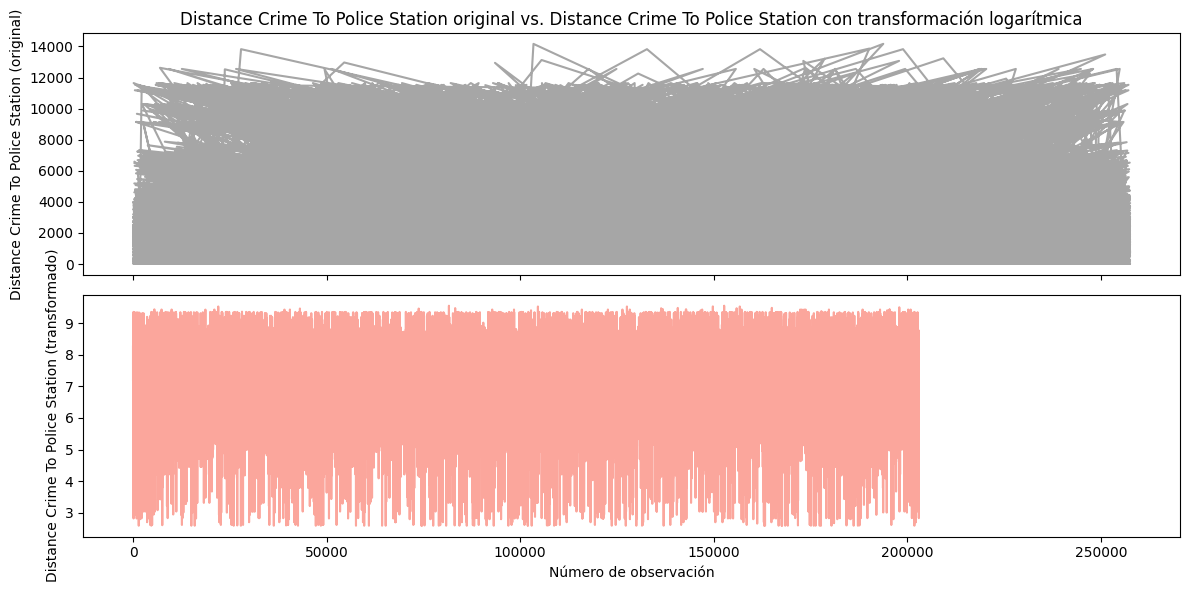

In [63]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 6), sharex=True)

# Primer gráfico: datos originales
axes[0].plot(df.index, df['Distance Crime To Police Station'], alpha=0.7, color='gray')
axes[0].set_ylabel('Distance Crime To Police Station (original)')
axes[0].set_title('Distance Crime To Police Station original vs. Distance Crime To Police Station con transformación logarítmica')

# Segundo gráfico: datos imputados
axes[1].plot(df_transformed.index, df_transformed['Distance Crime To Police Station'], alpha=0.7, color='salmon')
axes[1].set_ylabel('Distance Crime To Police Station (transformado)')
axes[1].set_xlabel('Número de observación')

plt.tight_layout()
plt.show()

In [64]:
df_for_outliers = df_transformed[['Distance Crime To Police Station']]
Q1 = df_for_outliers.quantile(0.25)
Q3 = df_for_outliers.quantile(0.75)

IQR = Q3 - Q1
outliers_iqr = (df_for_outliers < (Q1 - 1.5 * IQR)) | (df_for_outliers > (Q3 + 1.5 * IQR))
print(f"Outliers\nDistance Crime To Police Station: <{Q1['Distance Crime To Police Station'] - 1.5 * IQR['Distance Crime To Police Station']:.02f} o >{Q3['Distance Crime To Police Station'] + 1.5 * IQR['Distance Crime To Police Station']:.02f}")

Outliers
Distance Crime To Police Station: <6.02 o >8.91


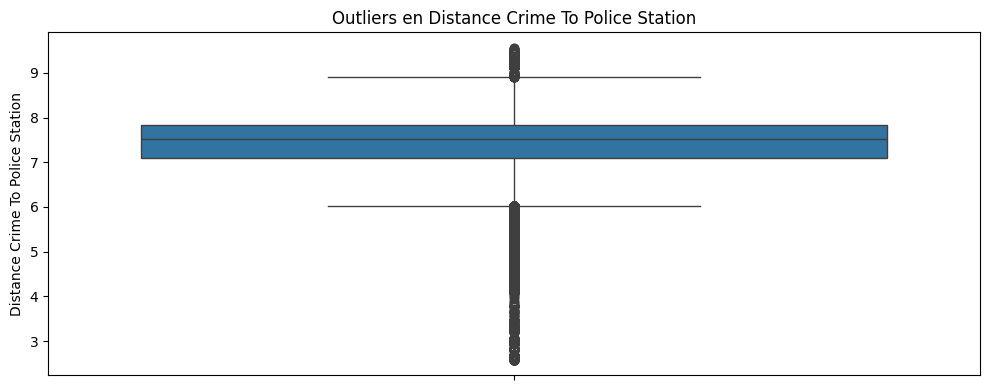

In [65]:
# Visualización de outliers con boxplots
fig, axes = plt.subplots(1, figsize=(10, 4))

# Boxplot para 'Distance Crime To Police Station'
sns.boxplot(y=df_for_outliers['Distance Crime To Police Station'], ax=axes)
axes.set_title('Outliers en Distance Crime To Police Station')

plt.tight_layout()
plt.show()

In [66]:
# Metodo basado en desviación estándar
mean = df_for_outliers.mean()
std = df_for_outliers.std()
# std = df_transformed.apply(lambda x: np.nanstd(x, ddof=1))

outliers_std = (df_for_outliers < (mean - 3 * std)) | (df_for_outliers > (mean + 3 * std))

print(f"Outliers\nDistance Crime To Police Station: <{mean['Distance Crime To Police Station'] - 3 * std['Distance Crime To Police Station']:.02f} o >{mean['Distance Crime To Police Station'] + 3 * std['Distance Crime To Police Station']:.02f}")

Outliers
Distance Crime To Police Station: <5.38 o >9.45


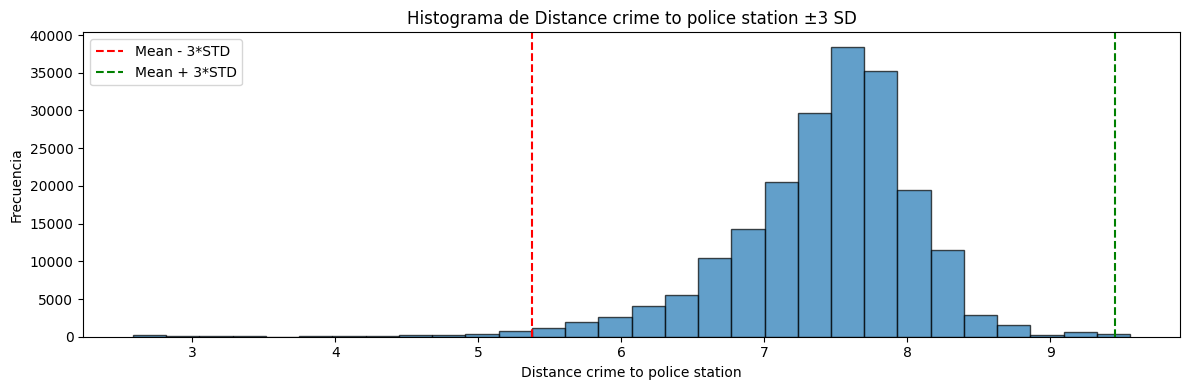

In [67]:
def plot_hist_with_std(ax, data, varname, mean, std):
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(mean[varname] - 3*std[varname], color='red', linestyle='--', label='Mean - 3*STD')
    ax.axvline(mean[varname] + 3*std[varname], color='green', linestyle='--', label='Mean + 3*STD')
    ax.set_xlabel(varname.capitalize())
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'Histograma de {varname.capitalize()} ±3 SD')
    ax.legend()

fig, ax = plt.subplots(1, figsize=(12, 4))

plot_hist_with_std(ax, df_for_outliers['Distance Crime To Police Station'], 'Distance Crime To Police Station', mean, std)

plt.tight_layout()
plt.show()

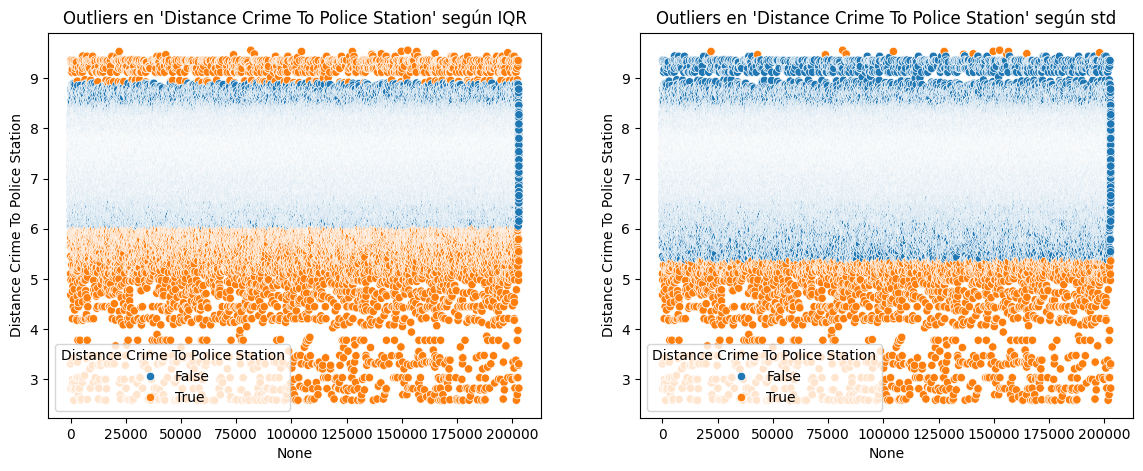

In [68]:
# Visualización con scatterplot
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=df_for_outliers.index, y=df_for_outliers['Distance Crime To Police Station'], hue=outliers_iqr['Distance Crime To Police Station'], ax=ax[0])
ax[0].set_title("Outliers en 'Distance Crime To Police Station' según IQR")
sns.scatterplot(x=df_for_outliers.index, y=df_for_outliers['Distance Crime To Police Station'], hue=outliers_std['Distance Crime To Police Station'], ax=ax[1])
ax[1].set_title("Outliers en 'Distance Crime To Police Station' según std")
plt.show()

In [69]:
df_transformed[outliers_std['Distance Crime To Police Station']==True]["Arrest"].value_counts()

Arrest
False    1897
True      574
Name: count, dtype: int64

In [70]:
df_no_outliers = df_transformed[~outliers_std.any(axis=1)].copy()
df_no_outliers.describe()

,Beat,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Crime District,Distance Crime To Police Station
count,200498.000000,200498.000000,200498.000000,2.004980e+05,2.004980e+05,200498.000000,200498.000000,200498.000000,200498.000000
mean,1155.734835,23.121243,36.333375,1.165248e+06,1.887519e+06,41.846935,-87.668987,11.327594,7.449088
std,708.424783,13.930460,21.588020,1.621242e+04,3.160707e+04,0.086915,0.051484,7.079148,0.595212
min,111.000000,1.000000,1.000000,1.097306e+06,1.813897e+06,41.644590,-87.768200,1.000000,5.377565
25%,533.000000,10.000000,22.000000,1.153896e+06,1.860271e+06,41.772058,-87.705488,5.000000,7.126992
50%,1033.000000,23.000000,32.000000,1.167058e+06,1.894154e+06,41.865245,-87.656973,10.000000,7.532987
75%,1731.000000,34.000000,53.000000,1.176684e+06,1.910375e+06,41.909874,-87.630560,17.000000,7.830528
max,2535.000000,50.000000,77.000000,1.205119e+06,1.951493e+06,42.022548,-87.568349,31.000000,9.443448


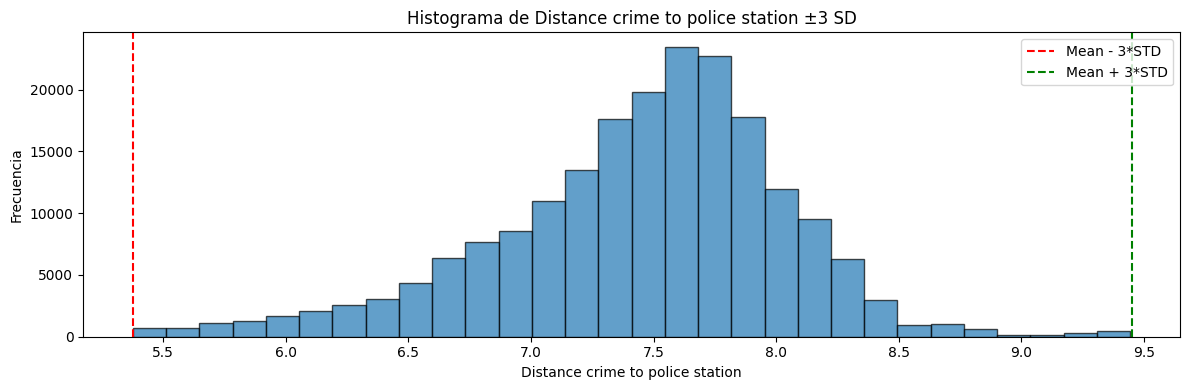

In [71]:
fig, ax = plt.subplots(1, figsize=(12, 4))

plot_hist_with_std(ax, df_no_outliers['Distance Crime To Police Station'], 'Distance Crime To Police Station', mean, std)

plt.tight_layout()
plt.show()

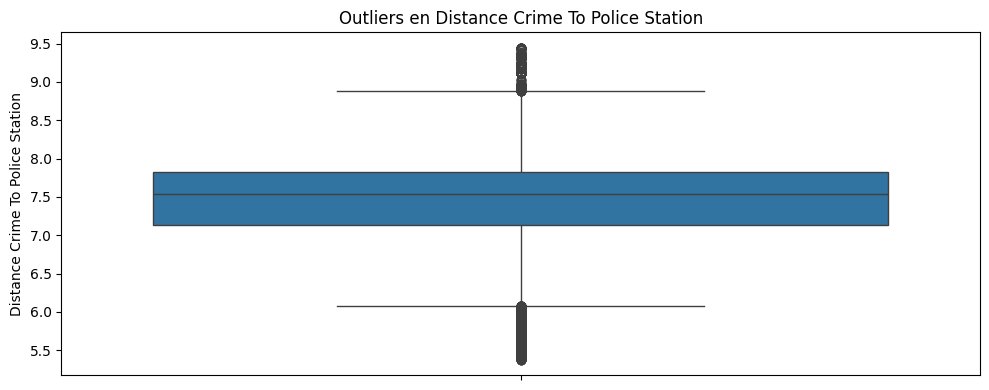

In [74]:
# Visualización de outliers con boxplots
fig, axes = plt.subplots(1, figsize=(10, 4))

# Boxplot para 'Distance Crime To Police Station'
sns.boxplot(y=df_no_outliers['Distance Crime To Police Station'], ax=axes)
axes.set_title('Outliers en Distance Crime To Police Station')

plt.tight_layout()
plt.show()

## Codificación (encoding)



In [75]:
df_no_outliers = df_no_outliers.copy()

# Convertimos columnas del dataset del crimen al tipo correcto datos de Entrenamiento
df_no_outliers['IUCR'] = df_no_outliers['IUCR'].astype('category')
df_no_outliers['Primary Type'] = df_no_outliers['Primary Type'].astype('category')
df_no_outliers['Location Description'] = df_no_outliers['Location Description'].astype('category')
df_no_outliers['FBI Code'] = df_no_outliers['FBI Code'].astype('category')
df_no_outliers['Arrest'] = df_no_outliers['Arrest'].astype('category')
df_no_outliers['Domestic'] = df_no_outliers['Domestic'].astype('category')
df_no_outliers['Crime District'] = df_no_outliers['Crime District'].astype('category')
df_no_outliers['Nearest Police Station District'] = df_no_outliers['Nearest Police Station District'].astype('category')
df_no_outliers['Nearest Police Station District Name'] = df_no_outliers['Nearest Police Station District Name'].astype('category')
df_no_outliers['Season'] = df_no_outliers['Season'].astype('category')
df_no_outliers['Day'] = df_no_outliers['Day'].astype('category')
df_no_outliers['Day Time'] = df_no_outliers['Day Time'].astype('category')

In [76]:

test_df_transformed = test_df_transformed.copy()

# Convertimos columnas del dataset del crimen al tipo correcto datos de test
test_df_transformed['IUCR'] = test_df_transformed['IUCR'].astype('category')
test_df_transformed['Primary Type'] = test_df_transformed['Primary Type'].astype('category')
test_df_transformed['Location Description'] = test_df_transformed['Location Description'].astype('category')
test_df_transformed['FBI Code'] = test_df_transformed['FBI Code'].astype('category')
test_df_transformed['Arrest'] = test_df_transformed['Arrest'].astype('category')
test_df_transformed['Domestic'] = test_df_transformed['Domestic'].astype('category')
test_df_transformed['Crime District'] = test_df_transformed['Crime District'].astype('category')
test_df_transformed['Nearest Police Station District'] = test_df_transformed['Nearest Police Station District'].astype('category')
test_df_transformed['Nearest Police Station District Name'] = test_df_transformed['Nearest Police Station District Name'].astype('category')
test_df_transformed['Season'] = test_df_transformed['Season'].astype('category')
test_df_transformed['Day'] = test_df_transformed['Day'].astype('category')
test_df_transformed['Day Time'] = test_df_transformed['Day Time'].astype('category')

In [77]:
df_no_outliers.describe(include='category')

,IUCR,Primary Type,Location Description,Arrest,Domestic,FBI Code,Crime District,Nearest Police Station District,Nearest Police Station District Name,Season,Day,Day Time
count,200498,200498,200498,200498,200498,200498,200498,200498,200498,200498,200498,200498
unique,331,31,126,2,2,26,23,23,23,4,7,4
top,0486,THEFT,STREET,False,False,06,8,3,Grand Crossing,Summer,Monday,Afternoon
freq,16033,45724,54816,173222,163198,46333,13491,18942,18942,54458,29580,62171


### Cyclic Encoding
Transforma variables cíclicas (como horas del día o meses del año) en coordenadas en un círculo.


In [78]:
# Codificación cíclica de la variable 'Day' para datos de entrenamiento
df_no_outliers["Day_num"] = df_no_outliers["Day"].map({
    "Sunday": 1, "Monday": 2, "Tuesday": 3, "Wednesday": 4, "Thursday": 5, "Friday": 6, "Saturday": 7
}).astype(int)

In [79]:
# Codificación cíclica de la variable 'Day' para datos de test
test_df_transformed["Day_num"] = test_df_transformed["Day"].map({
    "Sunday": 1, "Monday": 2, "Tuesday": 3, "Wednesday": 4, "Thursday": 5, "Friday": 6, "Saturday": 7
}).astype(int)

In [80]:
df_no_outliers["Day_sin"] = np.sin(2 * np.pi * df_no_outliers["Day_num"] / 7)

In [81]:
test_df_transformed["Day_sin"] = np.sin(2 * np.pi * test_df_transformed["Day_num"] / 7)

### One-Hot encoding datos de entrenamiento
Crea una columna binaria (0/1) para cada categoría.


In [82]:
df_no_outliers = df_no_outliers.reset_index()

In [83]:
# Inicializar el OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)

# Fit + transform
encoded_array = ohe.fit_transform(df_no_outliers[["Season"]])  # Ojo! me devuelve un array de NumPy
columns=ohe.get_feature_names_out(["Season"])

# Creo un DF a partir del array
encoded_df = pd.DataFrame(encoded_array, columns=ohe.get_feature_names_out(["Season"]))

# Lo juntamos con el df original (en este caso no eliminamos la columna original a modo demostrativo)
df_ohe = df_no_outliers.join(encoded_df)

In [84]:
# Inicializar el OneHotEncoder
ohe_2 = OneHotEncoder(sparse_output=False)

# Fit + transform
encoded_array = ohe_2.fit_transform(df_ohe[["Day Time"]])  # Ojo! me devuelve un array de NumPy
columns=ohe_2.get_feature_names_out(["Day Time"])

# Creo un DF a partir del array
encoded_df = pd.DataFrame(encoded_array, columns=ohe_2.get_feature_names_out(["Day Time"]))

# Lo juntamos con el df original (en este caso no eliminamos la columna original a modo demostrativo)
df_ohe_2 = df_ohe.join(encoded_df)

### One-Hot encoding datos de test
Crea una columna binaria (0/1) para cada categoría.


In [85]:
test_df_transformed = test_df_transformed.reset_index()

In [86]:
# Fit + transform
encoded_test_array = ohe.transform(test_df_transformed[["Season"]])  # Ojo! me devuelve un array de NumPy
test_columns = ohe.get_feature_names_out(["Season"])

# Creo un DF a partir del array
encoded_test_df = pd.DataFrame(encoded_test_array, columns=test_columns)

# Lo juntamos con el df original (en este caso no eliminamos la columna original a modo demostrativo)
test_df_ohe = test_df_transformed.join(encoded_test_df)

In [87]:
# Fit + transform
encoded_test_array = ohe_2.transform(test_df_ohe[["Day Time"]])  # Ojo! me devuelve un array de NumPy
test_columns=ohe_2.get_feature_names_out(["Day Time"])

# Creo un DF a partir del array
encoded_test_df = pd.DataFrame(encoded_test_array, columns=test_columns)

# Lo juntamos con el df original (en este caso no eliminamos la columna original a modo demostrativo)
test_df_ohe_2 = test_df_ohe.join(encoded_test_df)

### Label encoding

Asigna un número entero arbitrario a cada categoría (de la variable target).

In [88]:
df_label = df_ohe_2.copy()
test_df_label = test_df_ohe_2.copy()

In [89]:
df_label["Arrest_tag"] = df_label["Arrest"].astype(int)
df_label["Domestic_tag"] = df_label["Domestic"].astype(int)

test_df_label["Arrest_tag"] = test_df_label["Arrest"].astype(int)
test_df_label["Domestic_tag"] = test_df_label["Domestic"].astype(int)

In [90]:
columns_to_drop = ["Season", "Day", "Day_num", "Day Time", "index", "Arrest", "Domestic"]
df_label = df_label.drop(columns=columns_to_drop)
test_df_label = test_df_label.drop(columns=columns_to_drop)

### Frequency Encoding
Sustituye cada categoría por su frecuencia de aparición.


In [91]:
df_freq = df_label.copy()
test_df_freq = test_df_label.copy()

In [92]:
# 4. Frequency Encoding
categorical_cols = ["IUCR", "Primary Type", "Location Description", "FBI Code",
                      "Crime District", "Nearest Police Station District",
                      "Nearest Police Station District Name"]

test_df_freq[categorical_cols] = test_df_freq[categorical_cols].astype('object')

# Frequency encoding
for col in categorical_cols:
    freq_encoding = df_freq[col].value_counts(normalize=True)

    # Train
    df_freq[f"{col.replace(' ', '_')}_freq"] = df_freq[col].map(freq_encoding).astype(float)

    # Test con fillna
    test_df_freq[f"{col.replace(' ', '_')}_freq"] = test_df_freq[col].map(freq_encoding).fillna(0).astype(float)


In [93]:
columns_to_drop = ["IUCR", "Primary Type", "Location Description", "FBI Code", "Crime District", "Nearest Police Station District", "Nearest Police Station District Name"]
df_freq = df_freq.drop(columns=columns_to_drop)
test_df_freq = test_df_freq.drop(columns=columns_to_drop)

In [94]:
df_freq.describe()

,Beat,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Distance Crime To Police Station,Day_sin,Season_Autumn,...,Day Time_Night,Arrest_tag,Domestic_tag,IUCR_freq,Primary_Type_freq,Location_Description_freq,FBI_Code_freq,Crime_District_freq,Nearest_Police_Station_District_freq,Nearest_Police_Station_District_Name_freq
count,200498.000000,200498.000000,200498.000000,2.004980e+05,2.004980e+05,200498.000000,200498.000000,200498.000000,2.004980e+05,200498.000000,...,200498.000000,200498.000000,200498.000000,200498.000000,200498.000000,200498.000000,200498.000000,200498.000000,200498.000000,200498.000000
mean,1155.734835,23.121243,36.333375,1.165248e+06,1.887519e+06,41.846935,-87.668987,7.449088,6.370059e-03,0.252965,...,0.285155,0.136041,0.186037,0.039996,0.125012,0.135137,0.115559,0.048246,0.052476,0.052476
std,708.424783,13.930460,21.588020,1.621242e+04,3.160707e+04,0.086915,0.051484,0.595212,7.081135e-01,0.434712,...,0.451489,0.342833,0.389137,0.029143,0.074006,0.106745,0.074246,0.010772,0.022307,0.022307
min,111.000000,1.000000,1.000000,1.097306e+06,1.813897e+06,41.644590,-87.768200,5.377565,-9.749279e-01,0.000000,...,0.000000,0.000000,0.000000,0.000005,0.000010,0.000005,0.000010,0.000050,0.013172,0.013172
25%,533.000000,10.000000,22.000000,1.153896e+06,1.860271e+06,41.772058,-87.705488,7.126992,-7.818315e-01,0.000000,...,0.000000,0.000000,0.000000,0.010045,0.066105,0.023656,0.055592,0.039801,0.035931,0.035931
50%,1033.000000,23.000000,32.000000,1.167058e+06,1.894154e+06,41.865245,-87.656973,7.532987,-2.449294e-16,0.000000,...,0.000000,0.000000,0.000000,0.047567,0.111732,0.121438,0.085467,0.051572,0.048115,0.048115
75%,1731.000000,34.000000,53.000000,1.176684e+06,1.910375e+06,41.909874,-87.630560,7.830528,7.818315e-01,1.000000,...,1.000000,0.000000,0.000000,0.062819,0.179708,0.273399,0.149203,0.053796,0.066335,0.066335
max,2535.000000,50.000000,77.000000,1.205119e+06,1.951493e+06,42.022548,-87.568349,9.443448,9.749279e-01,1.000000,...,1.000000,1.000000,1.000000,0.079966,0.228052,0.273399,0.231090,0.067287,0.094475,0.094475


In [95]:
df_freq.dtypes

Beat                                           int64
Ward                                           int64
Community Area                                 int64
X Coordinate                                 float64
Y Coordinate                                 float64
Latitude                                     float64
Longitude                                    float64
Distance Crime To Police Station             float64
Day_sin                                      float64
Season_Autumn                                float64
Season_Spring                                float64
Season_Summer                                float64
Season_Winter                                float64
Day Time_Afternoon                           float64
Day Time_Early Morning                       float64
Day Time_Morning                             float64
Day Time_Night                               float64
Arrest_tag                                     int64
Domestic_tag                                  

## Salvamos en un archivo

In [98]:
df_freq.to_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded.csv", index=False)
test_df_freq.to_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded_test.csv", index=False)